ANN SU DATASET IRIS CON KERA: LA TUA PRIMA RETE NEURALE REALE.

Problema di classificazione

- Prepocessing dei dati: trasformazione dlele eticvhette tramite one-hot encoding
- Costruzione dell'architettura: il modello Sequential e la densità dei layer.
- Fase di addestramento: monitoraggio dell'accuratezza e interpretazione dei risultati.

Prepocessing dei dati (prima di dare i dati in pasto alla ANN)

CLASSIFICAZIONE IRIS CON RETI NEURALI (KERAS)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

1. CARICAMENTO DEI DATI E PREPROCESSING

* STANDARIZZAZIONE
Portiamo le feature a media zero e varianza unitaria. Questo aiuta l'ottimizzatore a convergere più velocemente.
* ONE-HOT ENCODING
Poichè abbiamo 3 classi, non possiamo usare numeri (0,1,2) perchè il modello penserebbe che la classe 2 sia 'più grande' della classe 0. Trasformiamo le etichette in valori binari [1,0,0]

In [20]:
iris = load_iris()
X = iris.data
y = iris.target

In [21]:
# 2. Standarizzazione per valocizzare il Gradient Descent

# per portare tutti i numeri su scala simile, media zero a varianza 1
# normalmente però la standarizzazione non va fatta prima di splittare i dati, ma in questo caso non è un problema
# solo per adesso, per semplificare il processo
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [22]:

# 3. Trasformazione in one-hot encoding
# se dicessio alla rete che le classi sono 0, 1, 2, potrebbe pensare che 2 è più simila a 1 che a 0, invece sono tutte e tre classi distrite
y=to_categorical(y)


2. SPLIT DEI DATI

In [23]:
# 4. Split dei dati: isoliamo il 20% per il test finale (dati che la rete non vedrà mai durante lo studio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print (f"Dataset preparato:\n- Train set: {X_train.shape[0]} campioni\n- Test set {X_test.shape[0]} campioni")


Dataset preparato:
- Train set: 120 campioni
- Test set 30 campioni


3. ARCHITETTURA SEQUANTIALE CON KERAS

Costruiamo la rete impilando i layer. Useremo:
- Un layer nascosto di attivazione ReLu (per evitare il problema del vanishing gradient)
- Un layer di output con Softmax, ideale per ottenere probabilità nette tra classi mutuamente esclusive (la somma delle probabilità in uscita sarà 1)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [28]:
#Costruzione del modello
model = Sequential([
    Input(shape=(4,)),              # definizione input (feature di ingresso)
    Dense(10, activation='relu'),   # hidden layer relu accende i neuroni in modo non lineare senza far sparire i neuroni
    Dense(8, activation='relu'), #layer aggiunto dopo
    Dense(3, activation='softmax')  # output layer (il risultato saranno 3 classi, la softmax schiccia i valori in uscita facendo schiacciare a 1, ottenendo una probabilità)
])
#compilazione del modello
model.compile(
    optimizer='adam', # sistema adattivo che impara la velocità cui mouoversi
    loss='categorical_crossentropy', # per la loss, che punisce severamente il modello se è molto sicuro di una risposta sbagliata
    metrics=['accuracy'] # metrica di riferimento
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

4. TRAINING E MONITORAGGIO VISIVO
Addestriamo il modello.
Eseguiamo il metodo .fit(). Catturiamo l'output nella variabile history, che contiene il registro di come l'errore (loss) è sceso dopo ogni epoca sia per l'addestramento che per la validazione

In [29]:
# Addestramento modello
history=model.fit(X_train,y_train,epochs=150,batch_size=8,validation_split=0.2,verbose=0)
#validation_split 0.2 mentre la rete studia sul training set, noi la controliamo su uno 0.2 di dati che estraiamo come reference
#epoche=100 i dati passano 100 volte all'interno della rete e passano in batch di 8 campioni alla volta, 
#fino a quando non ha esaurito tutto il dataset e quella è una epoca, poi ricomincia da capo

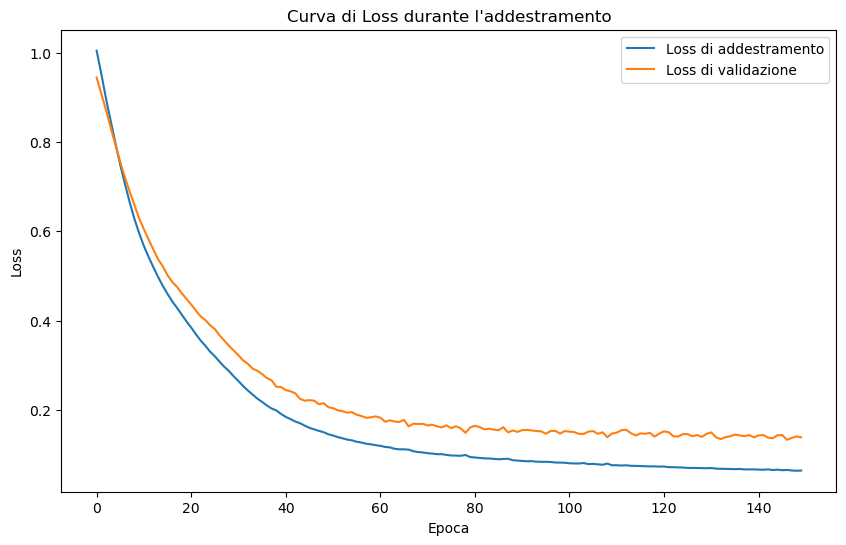

In [30]:
# Visualizzazione delle curve di loss
plt.figure(figsize=(10,6))
plt.plot(history .epoch, history.history['loss'], label='Loss di addestramento')
plt.plot(history.epoch, history.history['val_loss'], label='Loss di validazione')
plt.title('Curva di Loss durante l\'addestramento')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.show()

i dati passano 100 volte all'interno della rete, in batch di 8 dati, si allena, prende le 8 sucessive, finche non ha esaurito tutto il dataset e poi riparte in un'altra epoca

Non c'è rischio di overtiffing perchè la validation scende allo stesso modo della training.
Si può fare di meglio gestendo più aspetti
1) aumentando le epoche di addestramento (ma attenzione perchè il modello è salvato in RAM, pertanto devo ripartire da zero ricostruendo il modello)

Se il modello non è abbastanza complesso devo aumentare la complessita, esempio aggiungendo un layer interno